In [1]:
import gpboost as gpb
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
# Load data
data = pd.read_csv('C:/Files/GLAN_DATA/first_wave/downscale_data_60/data_with_activity_sequence_all_recod_downsampling_activity_travel.csv')
data = data[data['time_weight'] >= 5]
data = data[data['tree_height'] >= 0]
print(data.shape)
pred_vars = ['household_income', 'age', 'gender', 'education_level', 'employment_status', 'neighborhood_type',
             'work_study', 'housework', 'personal_affair', 'leisure',
             'travel', 'transportation', 'residence', 'industry', 'company', 'shopping',
             'restaurant', 'life_service', 'education_culture', 'entertainment', 'sport_fitness',
             'recreation_tourism', 'healthcare', 'workday', 'time_hour', 'mobility_status',
             'time_nonflexibility', 'home_ornot', 'POI_density', 'POI_diversity', "tree_height"]
# Prepare 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=666)
fold_results = []


(8427, 52)


C:\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import gpboost as gpb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

#, log=True
best_params = {
    'num_boost_round': 280,
    'learning_rate': 0.001292112722051777,
    'max_depth': 5,
    'num_leaves': 127,
    'min_data_in_leaf': 45,
    'lambda_l1': 22.605341824915648,
    'lambda_l2': 7.170332586173781,
    'feature_fraction': 0.7386048051720877,
    'min_gain_to_split': 4.374371803180026,
    'min_sum_hessian_in_leaf': 1.7580285746703073
}

final_params = best_params.copy()
final_params.update({'verbose': -1, 'objective': 'regression', 'metric': 'mse'})



gp_model = gpb.GPModel(group_data=data['pid'], likelihood='gaussian')
data_bst = gpb.Dataset(data=data[pred_vars], label=data['compound_exposure_disadvantage'])
gpbst = gpb.train(
    params=final_params,
    train_set=data_bst,
    gp_model=gp_model
)



pred_latent = gpbst.predict(
    data=data[pred_vars],
    group_data_pred=data['pid'],
    pred_latent=True
)
pred_fixed = pred_latent['fixed_effect']
pred_random = pred_latent['random_effect_mean']
pred_full = pred_fixed + pred_random

C:\anaconda3\envs\torch\lib\site-packages\gpboost\engine.py:183: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  _log_warning("Found `{}` in params. Will use it instead of argument".format(alias))


In [3]:
gp_model.summary()
var_error_term=gp_model.get_cov_pars()["Error_term"]
var_random_effects=gp_model.get_cov_pars()["pid"]
var_fixed_effects=np.var(pred_fixed)
icc= var_random_effects/(var_random_effects+var_error_term)
marginal_r2= var_fixed_effects/(var_error_term+var_random_effects+var_fixed_effects)
condition_r2=(var_fixed_effects+var_random_effects)/(var_error_term+var_random_effects+var_fixed_effects)
print(f"var_fixed_effects:{var_fixed_effects}")
print(f"ICC: {icc}")
print(f"Marginal R²: {marginal_r2}")
print(f"Condition R²: {condition_r2}")

Model summary:
Nb. observations: 8427
Nb. groups: 749 (pid)
Covariance parameters (random effects):
            Param.
Error_term  0.0060
pid         0.0043
var_fixed_effects:0.03142662599965965
ICC: Param.    0.419414
dtype: float64
Marginal R²: Param.    0.751968
dtype: float64
Condition R²: Param.    0.855996
dtype: float64


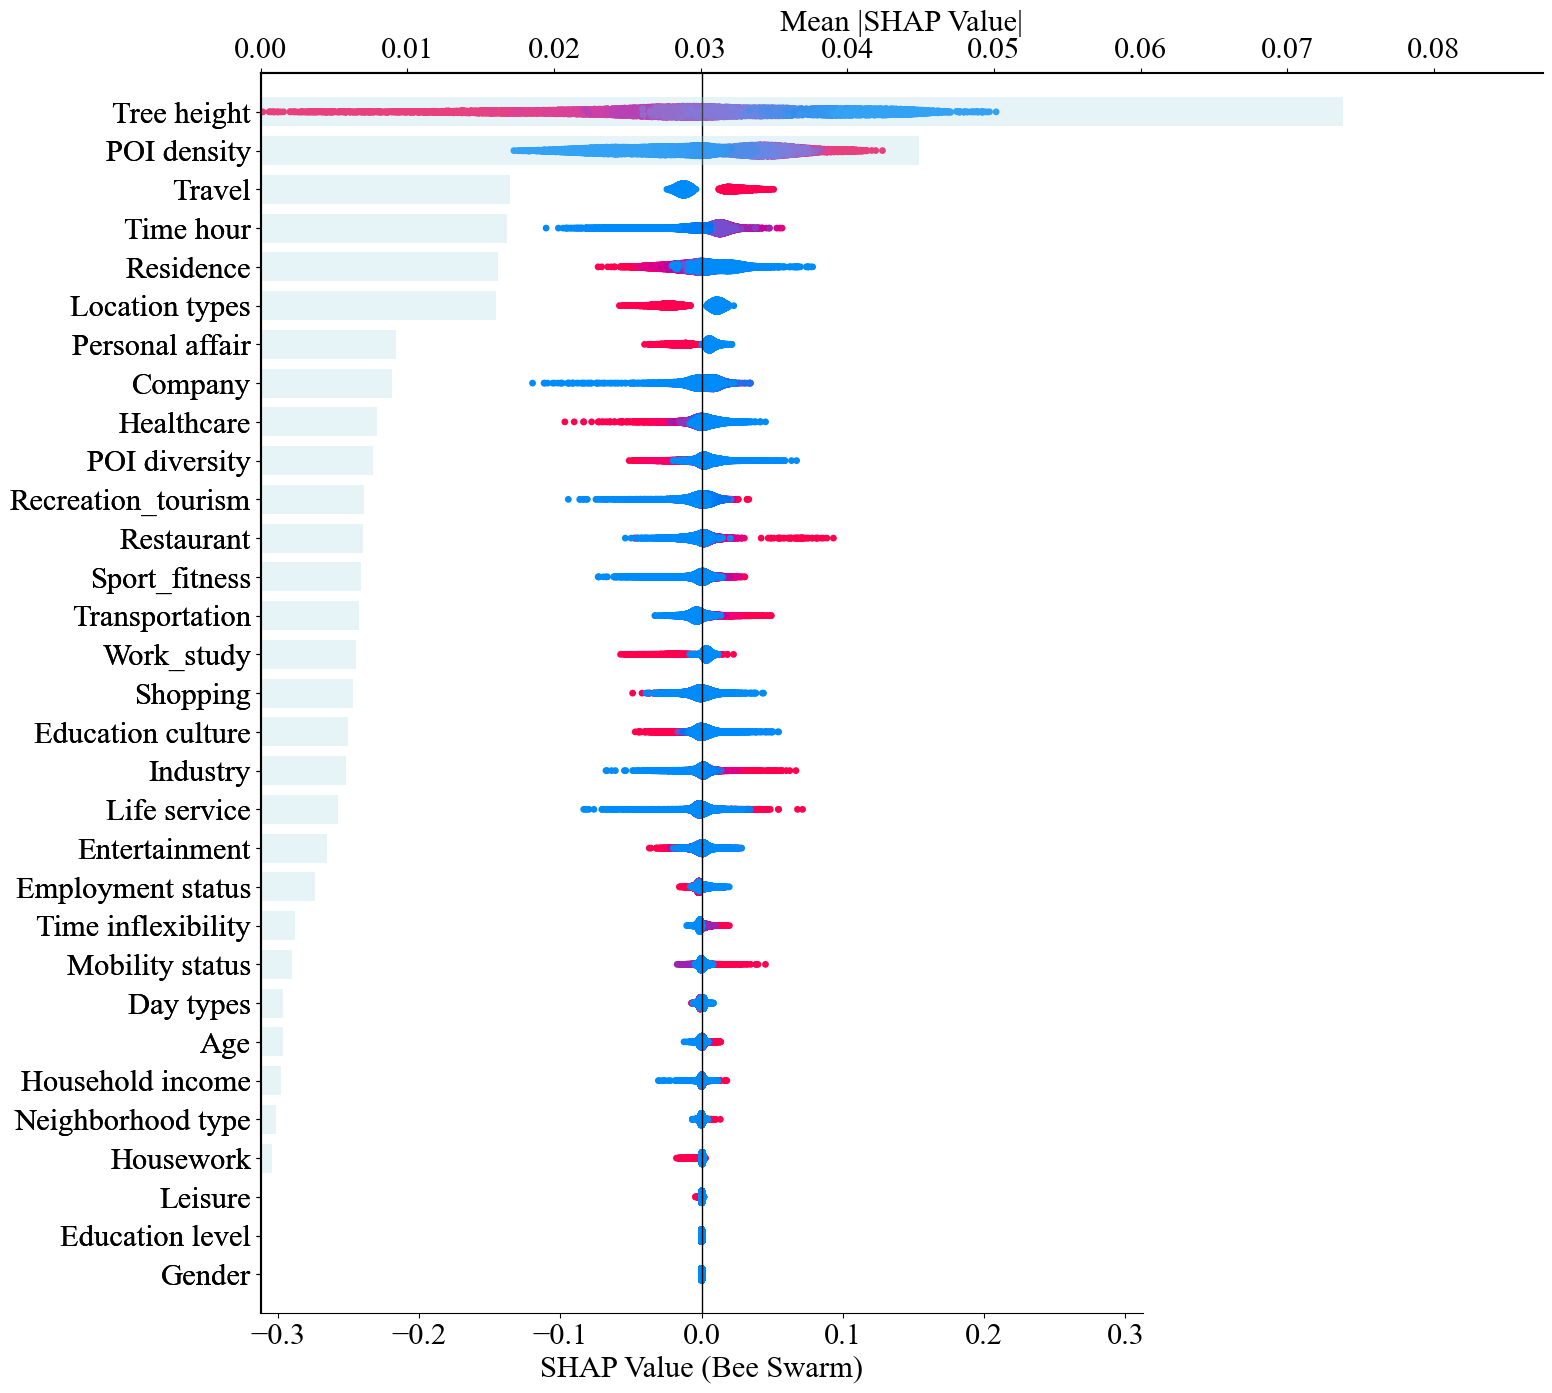

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import shap
import pandas as pd
from shap.plots.colors import red_blue

shap_values = shap.TreeExplainer(gpbst).shap_values(data[pred_vars])
# Feature names
feature_names = [
    'Household income', 'Age', 'Gender', 'Education level', 'Employment status',
    'Neighborhood type', 'Work_study', 'Housework', 'Personal affair', 'Leisure',
    'Travel', 'Transportation', 'Residence', 'Industry', 'Company', 'Shopping',
    'Restaurant', 'Life service', 'Education culture', 'Entertainment', 'Sport_fitness',
    'Recreation_tourism', 'Healthcare', 'Day types', 'Time hour', 'Mobility status',
    'Time inflexibility', 'Location types', 'POI density', 'POI diversity',"Tree height"
]


data_=data[pred_vars]
df = data_
#print(df)
mean_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_mean_shap = mean_shap[sorted_idx]

# Plot settings
n_features = len(sorted_features)
bar_width_val = 42
bar_height = 1.5 * bar_width_val
spacing = 2 * bar_width_val
fig = plt.figure(figsize=(14, max(8, n_features * 0.5)))
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['xtick.labelsize'] = 22
plt.rcParams['ytick.labelsize'] = 22
max_shap = np.abs(shap_values).max() * 1
max_shap_bar = max_shap * 0.28


ax1 = fig.add_axes([0.10, 0.10, 0.63, 0.8])  # Bee swarm plot
ax2 = fig.add_axes([0.10, 0.10, 0.9157, 0.8], sharey=ax1, frameon=True)  # Bar plot
ax2.patch.set_alpha(0)
ax1.tick_params(axis='both', which='major', labelsize=22)
ax2.tick_params(axis='both', which='major', labelsize=22)


cmap = red_blue
norm = Normalize(vmin=0, vmax=1)


for i, idx in enumerate(sorted_idx):
    shap_vals = shap_values[:, idx]
    feature_vals = df.iloc[:, idx].values

    
    cvals = feature_vals.astype(np.float64)
    vmin, vmax = np.percentile(cvals, [10, 90])
    cvals = (cvals - vmin) / (vmax - vmin + 1e-8)
    cvals = np.clip(cvals, 0, 1)

    
    sorted_order = np.argsort(cvals)[::-1]
    shap_vals = shap_vals[sorted_order]
    cvals = cvals[sorted_order]

    
    if np.std(shap_vals) < 1e-6:  
        density = np.ones_like(shap_vals) * 0.3 
    else:
        try:
            kde = gaussian_kde(shap_vals)
            density = kde(shap_vals) / np.max(kde(shap_vals)) * 0.3
        except np.linalg.LinAlgError:
            density = np.ones_like(shap_vals) * 0.3  

    # Scatter plot
    y_pos = (n_features - 1 - i) * spacing + np.random.uniform(-density, density, size=len(shap_vals)) * bar_width_val
    ax1.scatter(shap_vals, y_pos, c=cvals, cmap=cmap, alpha=1, s=15)


bar_positions = np.arange(n_features)[::-1] * spacing
ax2.barh(bar_positions, sorted_mean_shap, height=bar_height, alpha=0.3, color='#ADD8E6')


ax1.set_yticks(bar_positions)
ax1.set_yticklabels(sorted_features)
ax1.set_xlim(-max_shap, max_shap)
ax2.set_xlim(0, max_shap_bar)
ax1.axvline(0, color='k', linewidth=1)


ax1.spines['right'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_visible(True)
    for spine in ['top', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.5)
ax1.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_ticks_position('top')


ax1.set_xlabel('SHAP Value (Bee Swarm)', fontsize=22)
ax2.set_xlabel('Mean |SHAP Value|', fontsize=22)
ax2.xaxis.set_label_position('top')
ax2.xaxis.get_label().set_position((0.5, 20))
ax1.set_ylim(-spacing, n_features * spacing)
ax1.set_yticklabels(sorted_features, fontsize=22)

# # Add colorbar
# cbar_ax = fig.add_axes([0.95, 0.18, 0.02, 0.64])
# sm = ScalarMappable(cmap=cmap, norm=norm)
# cbar = plt.colorbar(sm, cax=cbar_ax)
# cbar.set_ticks([0, 1])
# cbar.set_ticklabels(['Low', 'High'])
# cbar.ax.yaxis.set_label_position('left')
# cbar.ax.yaxis.set_ticks_position('right')
# cbar.ax.tick_params(labelsize=22)
# cbar.set_label('Feature Value', fontsize=22)

# Save and show
plt.savefig('shap_summary_plot_exposure_disadvantage.pdf', format='pdf', bbox_inches='tight')
plt.savefig('shap_summary_plot_exposure_disadvantage.tif', format='tif', bbox_inches='tight', dpi=1000)
plt.show()

In [4]:

def extract_previous_five_exposures(df):
    df_sorted = df.sort_values(['pid', 'activity_sequence_all']).copy()
    for i in range(1, 6):
        df_sorted[f'compound_exposure_previous_{i}'] = np.nan
    for idx, row in df_sorted.iterrows():
        pid = row['pid']
        seq = row['activity_sequence_all']
        previous_activities = df_sorted[
            (df_sorted['pid'] == pid) & 
            (df_sorted['activity_sequence_all'] < seq)
        ].sort_values('activity_sequence_all', ascending=False)  # Sort descending: closest first
        
        exposures = previous_activities['compound_exposure_disadvantage'].head(5).values
        padded = np.pad(exposures, (0, 5 - len(exposures)), mode='constant', constant_values=np.nan)
        for i in range(5):
            df_sorted.at[idx, f'compound_exposure_previous_{i+1}'] = padded[i]
    
    return df_sorted


data_timeauto = extract_previous_five_exposures(data)
print(data_timeauto.shape)

timeauto_predictors = [
    'household_income', 'age', 'gender', 'education_level', 'employment_status', 'neighborhood_type',
    'work_study', 'housework', 'personal_affair', 'leisure',
    'travel', 'transportation', 'residence', 'industry', 'company', 'shopping',
    'restaurant', 'life_service', 'education_culture', 'entertainment', 'sport_fitness',
    'recreation_tourism', 'healthcare', 'workday', 'time_hour', 'mobility_status',
    'time_nonflexibility', 'home_ornot', 'POI_density', 'POI_diversity', 'tree_height',
    'compound_exposure_previous_1', 'compound_exposure_previous_2', 'compound_exposure_previous_3', 
    'compound_exposure_previous_4', 'compound_exposure_previous_5'
]


best_params = {
    'num_boost_round': 280,
    'learning_rate': 0.001292112722051777,
    'max_depth': 5,
    'num_leaves': 127,
    'min_data_in_leaf': 45,
    'lambda_l1': 22.605341824915648,
    'lambda_l2': 7.170332586173781,
    'feature_fraction': 0.7386048051720877,
    'min_gain_to_split': 4.374371803180026,
    'min_sum_hessian_in_leaf': 1.7580285746703073
}

final_params = best_params.copy()
final_params.update({'verbose': -1, 'objective': 'regression', 'metric': 'mse'})


gp_model = gpb.GPModel(group_data=data_timeauto['pid'], likelihood='gaussian')


data_bst = gpb.Dataset(data=data_timeauto[timeauto_predictors], label=data_timeauto['compound_exposure_disadvantage'])

gpbst = gpb.train(
    params=final_params,
    train_set=data_bst,
    gp_model=gp_model
)


(8427, 57)


C:\anaconda3\envs\torch\lib\site-packages\gpboost\engine.py:183: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  _log_warning("Found `{}` in params. Will use it instead of argument".format(alias))


Mean Absolute SHAP Values for Previous Exposure Variables:
compound_exposure_previous_1: 0.0234
compound_exposure_previous_2: 0.0042
compound_exposure_previous_3: 0.0034
compound_exposure_previous_4: 0.0037
compound_exposure_previous_5: 0.0066


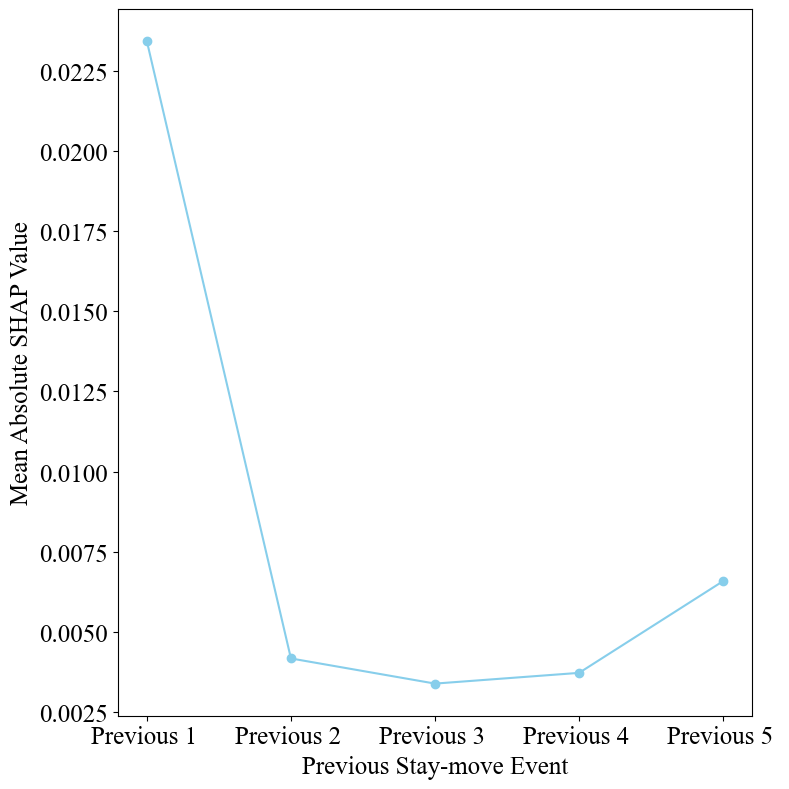

In [10]:
import shap
import matplotlib.pyplot as plt
shap_values = shap.TreeExplainer(gpbst).shap_values(data_timeauto[timeauto_predictors])

shap_df = pd.DataFrame(shap_values, columns=timeauto_predictors)
prev_exposure_cols = [f'compound_exposure_previous_{i}' for i in range(1, 6)]
mean_abs_shap = shap_df[prev_exposure_cols].abs().mean()


print("Mean Absolute SHAP Values for Previous Exposure Variables:")
for col, val in mean_abs_shap.items():
    print(f"{col}: {val:.4f}")


plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.serif'] = ['Times New Roman']

# Create a line plot using matplotlib and save as PDF
plt.figure(figsize=(8, 8))
plt.plot(range(1, 6), mean_abs_shap, marker='o', linestyle='-', color='skyblue', label='Mean Absolute SHAP Value')
plt.xlabel('Previous Stay-move Event', fontsize=18, fontfamily='Times New Roman')
plt.ylabel('Mean Absolute SHAP Value', fontsize=18, fontfamily='Times New Roman')
plt.xticks(range(1, 6), [f'Previous {i} ' for i in range(1, 6)], 
           fontsize=18, fontfamily='Times New Roman')
plt.yticks(fontsize=18, fontfamily='Times New Roman')
plt.grid(False)  # Remove grid
#plt.legend(fontsize=18, prop={'family': 'Times New Roman'})
plt.tight_layout()
plt.savefig('shap_contributions_timeauto.pdf', format='pdf', bbox_inches='tight')
plt.show()